<a href="https://colab.research.google.com/github/kavinraajs04/NLP_Projects/blob/main/Project_7_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('vader_lexicon')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [17]:
data = {

"Review":[

# Positive Reviews

"The room was clean and spacious. The staff were very friendly and helpful.",
"The breakfast buffet had many delicious options and the service was excellent.",
"I loved the swimming pool and the hotel atmosphere was relaxing.",
"The check-in process was quick and the receptionist was polite.",
"Our family enjoyed the stay because the rooms were comfortable.",
"The housekeeping staff cleaned the room every day.",
"The hotel location was perfect and close to tourist attractions.",
"The bed was very comfortable and I slept peacefully.",
"The restaurant served tasty food with fast service.",
"The hotel offered great value for money with excellent facilities.",
"The staff upgraded our room without extra charge.",
"The hotel provided free airport pickup which was very convenient.",
"The room had an amazing city view.",
"The gym equipment was modern and clean.",
"The restaurant staff were friendly and attentive.",
"The hotel was beautifully decorated.",
"The bathroom was sparkling clean with fresh towels.",
"The complimentary breakfast exceeded expectations.",
"The children enjoyed the play area.",
"The hotel management responded quickly to our requests.",
"The WiFi speed was excellent throughout the hotel.",
"The conference hall was spacious and well maintained.",
"The garden area was peaceful and beautifully landscaped.",
"The security staff were polite and professional.",
"The overall experience was fantastic and memorable.",

# Negative Reviews

"The room was dirty and the bathroom smelled bad.",
"The air conditioner was not working during the entire stay.",
"The hotel staff behaved rudely and ignored our complaints.",
"The food quality was poor and dinner was served cold.",
"The room service was extremely slow.",
"The bedsheets were stained and not changed.",
"There was too much noise during the night.",
"The WiFi connection was very slow.",
"The swimming pool was closed without notice.",
"The parking area was overcrowded and unsafe.",
"The receptionist took a long time to complete check-in.",
"The bathroom had leaking pipes.",
"The room was too small for the price.",
"The elevator stopped working several times.",
"The staff were unprofessional during checkout.",
"The food was overpriced and tasteless.",
"The hotel was not properly maintained.",
"The air conditioning produced loud noise.",
"The towels were old and dirty.",
"The internet disconnected frequently.",
"The room smelled of cigarette smoke.",
"The television was not functioning properly.",
"The lobby was crowded and noisy.",
"The hot water was unavailable in the morning.",
"The hotel did not meet our expectations."

],

"Sentiment":[

"Positive","Positive","Positive","Positive","Positive",
"Positive","Positive","Positive","Positive","Positive",
"Positive","Positive","Positive","Positive","Positive",
"Positive","Positive","Positive","Positive","Positive",
"Positive","Positive","Positive","Positive","Positive",

"Negative","Negative","Negative","Negative","Negative",
"Negative","Negative","Negative","Negative","Negative",
"Negative","Negative","Negative","Negative","Negative",
"Negative","Negative","Negative","Negative","Negative",
"Negative","Negative","Negative","Negative","Negative"

]

}

df = pd.DataFrame(data)

df.head()

,Review,Sentiment
0,The room was clean and spacious. The staff wer...,Positive
1,The breakfast buffet had many delicious option...,Positive
2,I loved the swimming pool and the hotel atmosp...,Positive
3,The check-in process was quick and the recepti...,Positive
4,Our family enjoyed the stay because the rooms ...,Positive


In [18]:
print(df.shape)

df.info()

df["Sentiment"].value_counts()

(50, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     50 non-null     object
 1   Sentiment  50 non-null     object
dtypes: object(2)
memory usage: 932.0+ bytes


,count
Sentiment,
Positive,25
Negative,25


In [19]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]','',text)

    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

df["Clean_Review"] = df["Review"].apply(preprocess)

df.head()

,Review,Sentiment,Clean_Review
0,The room was clean and spacious. The staff wer...,Positive,room clean spacious staff friendly helpful
1,The breakfast buffet had many delicious option...,Positive,breakfast buffet many delicious option service...
2,I loved the swimming pool and the hotel atmosp...,Positive,loved swimming pool hotel atmosphere relaxing
3,The check-in process was quick and the recepti...,Positive,checkin process quick receptionist polite
4,Our family enjoyed the stay because the rooms ...,Positive,family enjoyed stay room comfortable


In [20]:
sia = SentimentIntensityAnalyzer()

def predict_sentiment(text):

    score = sia.polarity_scores(text)

    if score["compound"] >= 0.05:
        return "Positive"

    elif score["compound"] <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Predicted_Sentiment"] = df["Clean_Review"].apply(predict_sentiment)

df.head()

,Review,Sentiment,Clean_Review,Predicted_Sentiment
0,The room was clean and spacious. The staff wer...,Positive,room clean spacious staff friendly helpful,Positive
1,The breakfast buffet had many delicious option...,Positive,breakfast buffet many delicious option service...,Positive
2,I loved the swimming pool and the hotel atmosp...,Positive,loved swimming pool hotel atmosphere relaxing,Positive
3,The check-in process was quick and the recepti...,Positive,checkin process quick receptionist polite,Neutral
4,Our family enjoyed the stay because the rooms ...,Positive,family enjoyed stay room comfortable,Positive


In [21]:
comparison = df[["Review","Sentiment","Predicted_Sentiment"]]

comparison.head(10)

,Review,Sentiment,Predicted_Sentiment
0,The room was clean and spacious. The staff wer...,Positive,Positive
1,The breakfast buffet had many delicious option...,Positive,Positive
2,I loved the swimming pool and the hotel atmosp...,Positive,Positive
3,The check-in process was quick and the recepti...,Positive,Neutral
4,Our family enjoyed the stay because the rooms ...,Positive,Positive
5,The housekeeping staff cleaned the room every ...,Positive,Neutral
6,The hotel location was perfect and close to to...,Positive,Positive
7,The bed was very comfortable and I slept peace...,Positive,Positive
8,The restaurant served tasty food with fast ser...,Positive,Neutral
9,The hotel offered great value for money with e...,Positive,Positive


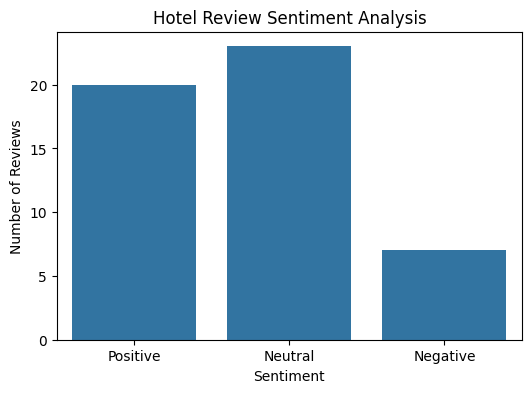

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(x="Predicted_Sentiment",data=df)

plt.title("Hotel Review Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

In [23]:
issues = {

"Room":["room","bed","bedsheet","bathroom"],

"Staff":["staff","manager","receptionist","housekeeping"],

"Food":["food","restaurant","breakfast","dinner"],

"Amenities":["wifi","pool","gym","parking","elevator","internet","air"],

"Cleanliness":["dirty","clean","smell","towel"]

}

In [24]:
def detect_issue(text):

    found=[]

    for category,words in issues.items():

        for word in words:

            if word in text:

                found.append(category)

                break

    if len(found)==0:

        return "Other"

    return ", ".join(found)

df["Issue"] = df["Clean_Review"].apply(detect_issue)

df[["Review","Issue"]].head()

,Review,Issue
0,The room was clean and spacious. The staff wer...,"Room, Staff, Cleanliness"
1,The breakfast buffet had many delicious option...,Food
2,I loved the swimming pool and the hotel atmosp...,Amenities
3,The check-in process was quick and the recepti...,Staff
4,Our family enjoyed the stay because the rooms ...,Room


In [25]:
df["Issue"].value_counts()

,count
Issue,
Other,14
Amenities,10
Room,7
Staff,5
Food,5
"Room, Cleanliness",3
"Room, Staff, Cleanliness",2
"Room, Staff",1
"Amenities, Cleanliness",1


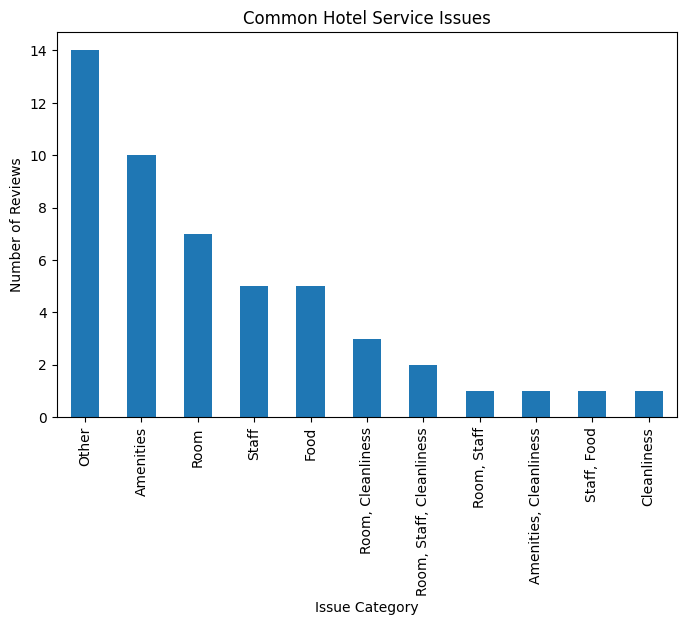

In [26]:
plt.figure(figsize=(8,5))

df["Issue"].value_counts().plot(kind="bar")

plt.title("Common Hotel Service Issues")

plt.xlabel("Issue Category")

plt.ylabel("Number of Reviews")

plt.show()

In [27]:
positive = (df["Predicted_Sentiment"]=="Positive").sum()

negative = (df["Predicted_Sentiment"]=="Negative").sum()

neutral = (df["Predicted_Sentiment"]=="Neutral").sum()
print(" Hotel Customer Satisfaction  report ")

print("Total Reviews :",len(df))

print("Positive Reviews :",positive)

print("Negative Reviews :",negative)

print("Neutral Reviews :",neutral)

print("\nMost Reported Issues")

print(df["Issue"].value_counts())

print("\nOverall Satisfaction :")

if positive > negative:
    print("Customers are generally SATISFIED.")

elif negative > positive:
    print("Customers are generally DISSATISFIED.")

else:
    print("Customer satisfaction is BALANCED.")

 Hotel Customer Satisfaction  report 
Total Reviews : 50
Positive Reviews : 20
Negative Reviews : 7
Neutral Reviews : 23

Most Reported Issues
Issue
Other                       14
Amenities                   10
Room                         7
Staff                        5
Food                         5
Room, Cleanliness            3
Room, Staff, Cleanliness     2
Room, Staff                  1
Amenities, Cleanliness       1
Staff, Food                  1
Cleanliness                  1
Name: count, dtype: int64

Overall Satisfaction :
Customers are generally SATISFIED.
